In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sales = pd.read_csv("../data/train2.csv")
sales.head() 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
sales.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
sales = sales.dropna()

In [ ]:
sales = sales.drop_duplicates()

In [10]:
sales.shape

(9789, 18)

In [12]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], dayfirst=True)

In [ ]:
# Add Month, Year, Quarter

sales["Month"] = sales["Order Date"].dt.month_name()
sales["Year"] = sales["Order Date"].dt.year
sales["Quarter"] = sales["Order Date"].dt.quarter

In [14]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month,Year,Quarter
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,November,2017,4
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,November,2017,4
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,June,2017,2
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,October,2016,4
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,October,2016,4


In [15]:
monthly_sales = sales.groupby("Month")["Sales"].sum()
monthly_sales

Month
April        134988.2506
August       157315.9270
December     321275.1395
February      59371.1154
January       91982.1396
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     345041.6110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64

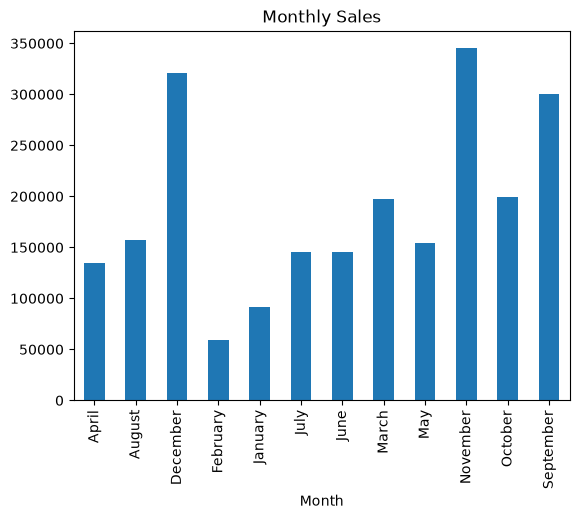

In [ ]:
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

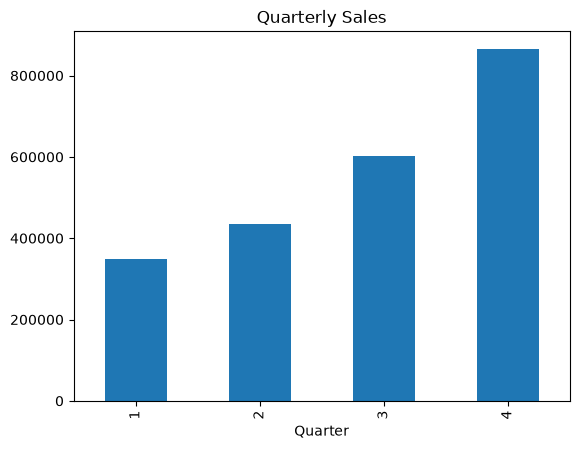

In [ ]:
quarter_sales = sales.groupby("Quarter")["Sales"].sum()

quarter_sales.plot(kind="bar")
plt.title("Quarterly Sales")
plt.show()  

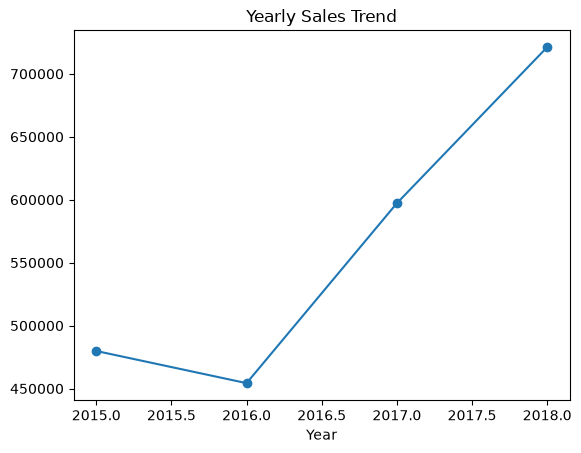

In [23]:
year_sales = sales.groupby("Year")["Sales"].sum()

year_sales.plot(kind="line", marker="o")
plt.title("Yearly Sales Trend")
plt.show()

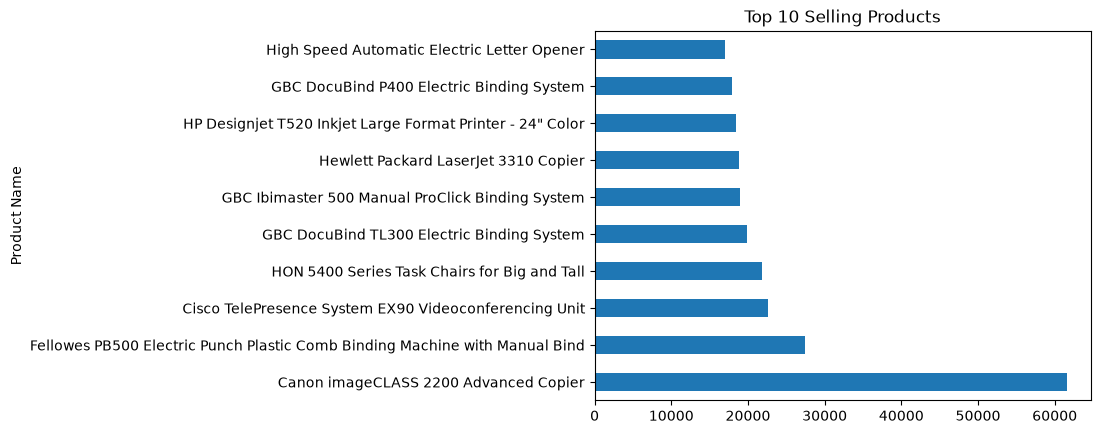

In [27]:
top_products = (
    sales.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind="barh")
plt.title("Top 10 Selling Products")
plt.show()

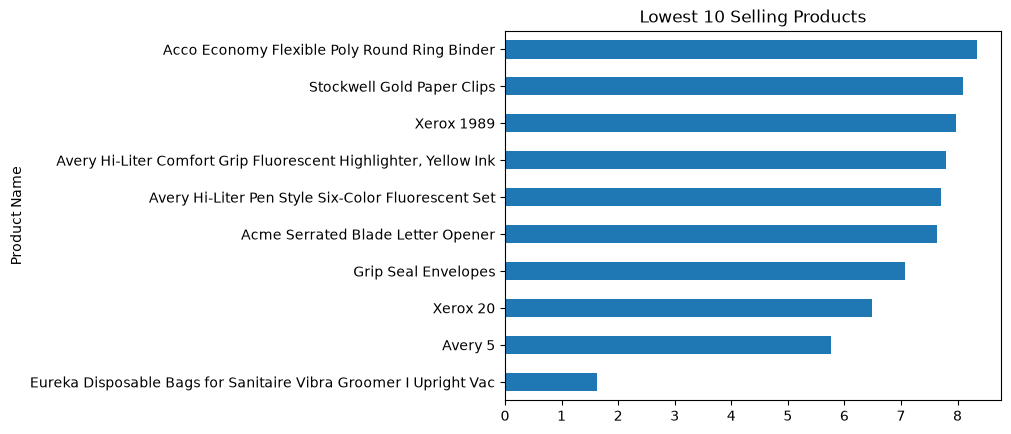

In [30]:
low_products = (
    sales.groupby("Product Name")["Sales"]
    .sum()
    .sort_values()
    .head(10)
)

low_products.plot(kind="barh")
plt.title("Lowest 10 Selling Products")
plt.show()

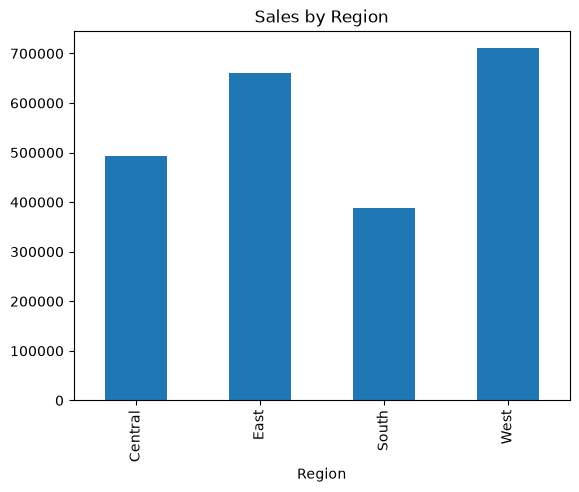

In [31]:
region_sales = sales.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

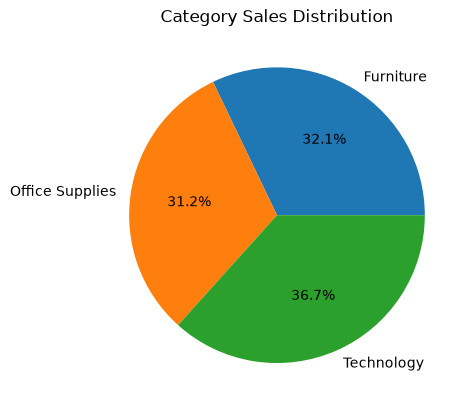

In [32]:
category_sales = sales.groupby("Category")["Sales"].sum()

category_sales.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Category Sales Distribution")
plt.show()

In [ ]:
# KPI 1: Total Revenue
total_revenue = sales["Sales"].sum()

# KPI 2: Total Orders
total_orders = sales["Order ID"].nunique()

# KPI 3: Number of Products
total_products = sales["Product Name"].nunique()

# KPI 4: Number of Categories
total_categories = sales["Category"].nunique()

growth_rate = (
    year_sales.pct_change().mean() * 100
)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Unique Products: {total_products}")
print(f"Categories: {total_categories}")
print(f"Growth Rate: {growth_rate:.2f}%")

sales["Order Date"] = pd.to_datetime(sales["Order Date"], dayfirst=True)

sales["Month"] = sales["Order Date"].dt.month_name()
sales["Year"] = sales["Order Date"].dt.year
sales["Quarter"] = sales["Order Date"].dt.quarter


Total Revenue: $2,261,536.78
Total Orders: 4922
Unique Products: 1849
Categories: 3
Growth Rate: 15.63%


: 